# YouTube Comment Sentiment Analysis — Data Inspection

This notebook performs an initial inspection of the raw YouTube comment dataset collected from three content domains: Technology, Travel, and Cats.

The objective is to understand the structure, quality, and characteristics of the collected data before applying any cleaning or sentiment analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/youtube_comments_750.csv")

df.head()

,domain,creator,video_id,video_title,comment_id,comment_text,like_count,published_at
0,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgzKqfHI8Eags5rqHVJ4AaABAg,Learned a lot of lessons from the last time I ...,4919,2026-09-18T15:56:48Z
1,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,Ugw2CZt8wqvMWpkUvml4AaABAg,18 pro series reporting lot of problems 😂pink ...,0,2026-09-26T17:23:15Z
2,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgxUGyHsxYZkzk7qHuF4AaABAg,What game is that??? 3:16,0,2026-09-26T16:45:06Z
3,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgyQxd36wlTmY5jj9_F4AaABAg,It's so cherry picking and most of the points ...,0,2026-09-26T16:19:00Z
4,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,Ugwh_zxyYLUROYEJKwF4AaABAg,"You’ve never had thermal issues?? Holy cow, I’...",0,2026-09-26T15:12:19Z


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   domain        750 non-null    str  
 1   creator       750 non-null    str  
 2   video_id      750 non-null    str  
 3   video_title   750 non-null    str  
 4   comment_id    750 non-null    str  
 5   comment_text  750 non-null    str  
 6   like_count    750 non-null    int64
 7   published_at  750 non-null    str  
dtypes: int64(1), str(7)
memory usage: 205.2 KB


In [4]:
df.dtypes

domain            str
creator           str
video_id          str
video_title       str
comment_id        str
comment_text      str
like_count      int64
published_at      str
dtype: object

In [5]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate comment IDs:", df["comment_id"].duplicated().sum())

Missing values:


domain          0
creator         0
video_id        0
video_title     0
comment_id      0
comment_text    0
like_count      0
published_at    0
dtype: int64


Duplicate rows: 0
Duplicate comment IDs: 0


In [6]:
df["domain"].value_counts()

domain
technology    250
travel        250
cats          250
Name: count, dtype: int64

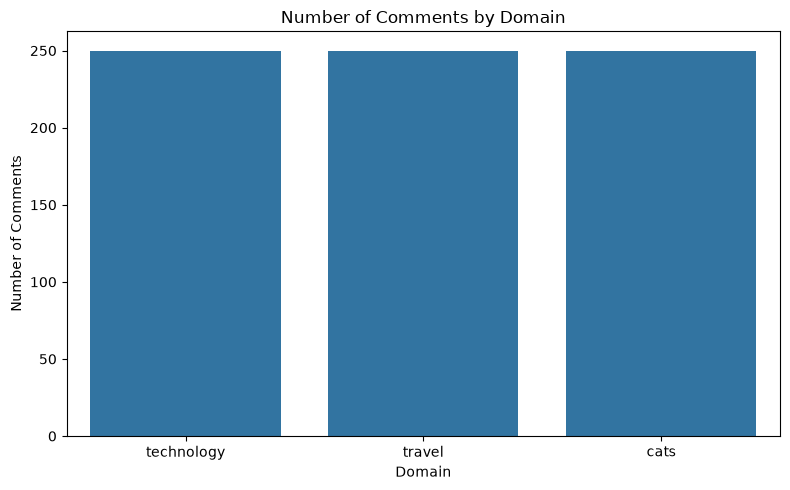

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="domain",
    order=["technology", "travel", "cats"]
)

plt.title("Number of Comments by Domain")
plt.xlabel("Domain")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

## Exploring Comment Text

In [8]:
pd.set_option("display.max_colwidth", 200)

df[["domain", "creator", "comment_text", "like_count"]].head(20)

,domain,creator,comment_text,like_count
0,technology,Mrwhosetheboss,Learned a lot of lessons from the last time I did this dual personality thing. Let me know how you found it!,4919
1,technology,Mrwhosetheboss,18 pro series reporting lot of problems 😂pink line issues durability issues,0
2,technology,Mrwhosetheboss,What game is that??? 3:16,0
3,technology,Mrwhosetheboss,It's so cherry picking and most of the points are easy to crack. Battery point is well taken. But imagine how much longer life it will get if it gets the silicon carbon battery with power efficien...,0
4,technology,Mrwhosetheboss,"You’ve never had thermal issues?? Holy cow, I’ve had thermal issues for the past two generations and I hardly do any gaming.",0
5,technology,Mrwhosetheboss,My IPhone 18 pro max keeps rebooting itself and freezing for some seconds,0
6,technology,Mrwhosetheboss,Sponsored by Apple! You did a better job convincing someone to buy this than Apple!,0
7,technology,Mrwhosetheboss,"Samsung Privacy display ""feature"" is such a scam. I got the same privacy display by buying an 10 EURO screen protector sticker. Literally the same effect. But the sticker actually provides actual ...",1
8,technology,Mrwhosetheboss,so i might get cancer in future i should start stocking up medicine and chemo therapy medics now cause who knows what will happen tommorow got it!,0
9,technology,Mrwhosetheboss,Apple and Oranges….. Yawn …. Make it more expensive so almost intelligent niche people buy it thinking that a phone upgrade makes them stand above others ….. what a sad bubble 😓😓…. Good marketing ...,0


In [9]:
df.sample(
    20,
    random_state=42
)[["domain", "comment_text", "like_count"]]

,domain,comment_text,like_count
506,cats,Kurt is loafing there like a ginger bread😂\nThe cats in the shelter will love it ❤,0
357,travel,Hello from Flagstaff! My girl and i are huge fans man! Love the videos! So exciting to see u get joyride form out target haha! Keep up the amazing videos!!❤,1
133,technology,I got one for $13 bucks on whatnot from dailydealzga fire guy to buy from 🔥,0
250,travel,Hidden message of the video.\nIt ALL ends with JESUS.,0
299,travel,I got 50/48🎉,0
680,cats,They dont sell in Canada if anyone can tell me where i could find this please DM me ❤,0
336,travel,I was in here😊😊😊😊,0
155,technology,"the 24mp output off nine 200mp shots is a waste, that stitching should've been the whole point. feels like the gimbal got finished before the software did",0
528,cats,I thought this was sambucha lmao 😭😭,0
736,cats,What I've learned about my cats is that you never give them treats straight away. You touch the button and say good boy then give them a pet then a treat. This seems to work for my cats.,0


## Comment Length

In [10]:
df["character_count"] = df["comment_text"].str.len()

df["word_count"] = (
    df["comment_text"]
    .str.split()
    .str.len()
)

df[["comment_text", "character_count", "word_count"]].head()

,comment_text,character_count,word_count
0,Learned a lot of lessons from the last time I did this dual personality thing. Let me know how you found it!,108,22
1,18 pro series reporting lot of problems 😂pink line issues durability issues,75,12
2,What game is that??? 3:16,25,5
3,It's so cherry picking and most of the points are easy to crack. Battery point is well taken. But imagine how much longer life it will get if it gets the silicon carbon battery with power efficien...,841,150
4,"You’ve never had thermal issues?? Holy cow, I’ve had thermal issues for the past two generations and I hardly do any gaming.",124,22


In [11]:
df[["character_count", "word_count"]].describe()

,character_count,word_count
count,750.000000,750.000000
mean,97.292000,18.568000
std,157.008155,29.216517
min,1.000000,1.000000
25%,27.250000,5.000000
50%,51.000000,10.000000
75%,115.000000,22.000000
max,2507.000000,466.000000


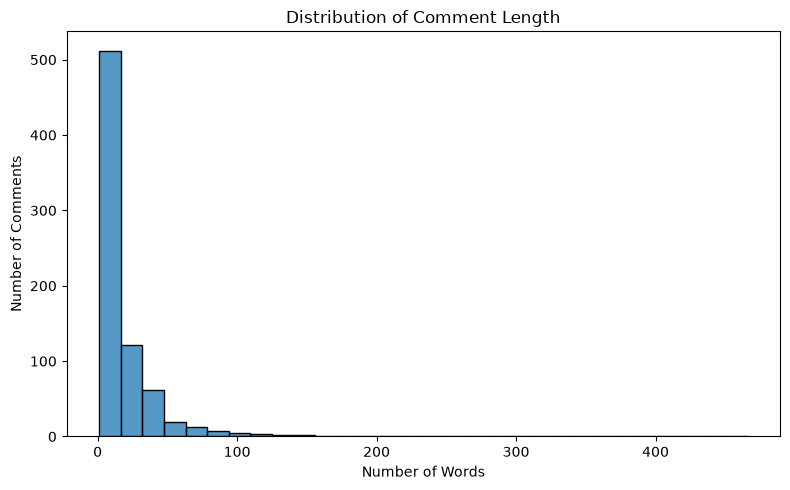

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="word_count",
    bins=30
)

plt.title("Distribution of Comment Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

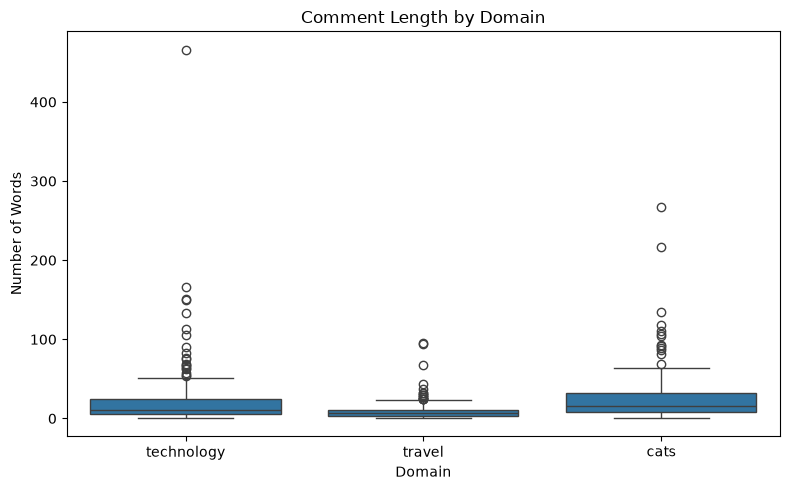

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="domain",
    y="word_count",
    order=["technology", "travel", "cats"]
)

plt.title("Comment Length by Domain")
plt.xlabel("Domain")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

## Comment Engagement

In [14]:
df["like_count"].describe()

count     750.000000
mean       12.940000
std       218.038024
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      4919.000000
Name: like_count, dtype: float64

In [15]:
df.groupby("domain")["like_count"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
domain,,,,
cats,250,0.336,0.0,36
technology,250,31.628,0.0,4919
travel,250,6.856,0.0,1636


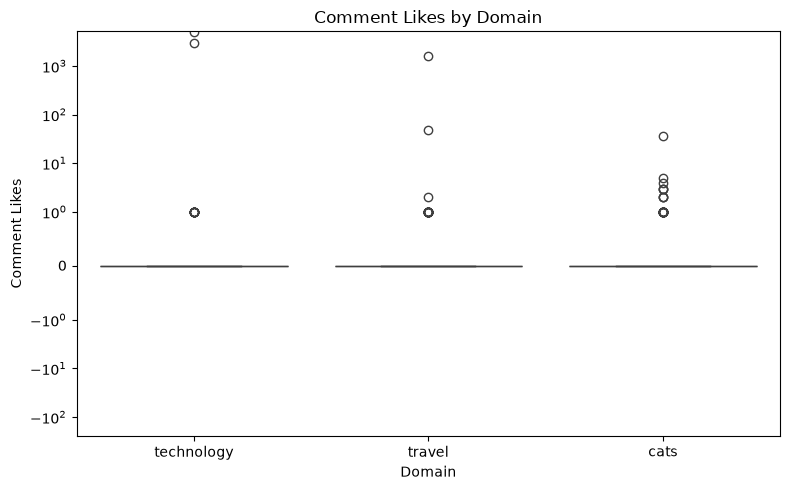

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="domain",
    y="like_count",
    order=["technology", "travel", "cats"]
)

plt.title("Comment Likes by Domain")
plt.xlabel("Domain")
plt.ylabel("Comment Likes")
plt.yscale("symlog", linthresh=1)
plt.tight_layout()
plt.show()

## Sampling Verification

The dataset was designed to contain 50 comments from each of 15 selected videos. The following checks verify that the intended sampling structure was preserved.

In [17]:
df.groupby(["domain", "creator"])["video_id"].nunique()

domain      creator       
cats        Abram Engle       5
technology  Mrwhosetheboss    5
travel      Ryan Trahan       5
Name: video_id, dtype: int64

In [18]:
comments_per_video = (
    df.groupby(["domain", "creator", "video_id"])
    .size()
    .reset_index(name="comment_count")
)

comments_per_video

,domain,creator,video_id,comment_count
0,cats,Abram Engle,D1sPbbd0Y14,50
1,cats,Abram Engle,SrqMV7uSg1c,50
2,cats,Abram Engle,_fC1khz15OA,50
3,cats,Abram Engle,eVp8utdVS30,50
4,cats,Abram Engle,hVhi6uL-l00,50
5,technology,Mrwhosetheboss,DNRYkBMaf3Y,50
6,technology,Mrwhosetheboss,Eo5w2S-h5dI,50
7,technology,Mrwhosetheboss,PjAyUhf52D0,50
8,technology,Mrwhosetheboss,VTLnDqjfRZQ,50
9,technology,Mrwhosetheboss,n3F996g8wjg,50


In [19]:
print("Total comments:", len(df))
print("Unique videos:", df["video_id"].nunique())
print("Unique creators:", df["creator"].nunique())
print("Domains:", df["domain"].nunique())

print("\nComments per domain:")
print(df["domain"].value_counts())

Total comments: 750
Unique videos: 15
Unique creators: 3
Domains: 3

Comments per domain:
domain
technology    250
travel        250
cats          250
Name: count, dtype: int64


## Very Short Comments

Very short comments may require special consideration during text preprocessing because they can contain limited textual information while still carrying sentiment through emojis, punctuation, or other expressions.

In [20]:
short_comments = df[df["word_count"] <= 2]

print("Comments with 2 words or fewer:", len(short_comments))

short_comments[
    ["domain", "comment_text", "like_count"]
].head(30)

Comments with 2 words or fewer: 82


,domain,comment_text,like_count
11,technology,iPhone ad,0
27,technology,Crap.,0
31,technology,Israel chip,0
34,technology,nice phone,0
49,technology,Unsubscribed,0
52,technology,Technologia.,0
68,technology,🤍🔥,0
79,technology,Chile tecnology:,1
84,technology,lg sponsor,0
88,technology,Chile:,0


## Initial Observations

The initial inspection confirms that the dataset contains 750 comments collected evenly across the three domains and 15 selected videos.

The comment text is predominantly short, although some comments are substantially longer. Comment likes are highly skewed, with most comments receiving no likes and a small number receiving much higher engagement.

A notable proportion of comments are very short, suggesting that preprocessing should preserve short expressions, emojis, and other sentiment-bearing elements rather than removing them solely based on length.

These observations will guide the data-cleaning and exploratory analysis stages.